---
<img style="float: right; margin: 15px 15px 15px 15px;" src="https://images.seeklogo.com/logo-png/51/2/reddit-logo-png_seeklogo-511297.png" width="350px" height="120px" />

# <font color=#bbc28d>**AITA — Moral Judgment LLM**</font>
#### <font color=#2E9AFE>`Dataset Preparation Pipeline`</font>

---

## <font color= #66b0b0> &ensp; • **Overview** </font>

This notebook evaluates the fine-tuned AITA model against examples it has never seen. After an initial diagnostic phase — where we tested the model on 40 hand-crafted examples with clear, unambiguous verdicts — we identified a systematic bias toward ESH and NAH driven by how the training data was cleaned.

This is due to the clear difference on how reddit posts are often writteng with lots of rambling and unimportant information, so we processed some examples as we did for the training phase to be fair to the way the model was procesed.

In future version's of the project, new ways of processing and cleaning the data may be taken to preserve more of the human essence in the written examples.



## <font color= #66b0b0> &ensp; • **Dependencies** </font>

In [1]:
!pip install -q transformers peft bitsandbytes datasets accelerate trl sentencepiece scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 44.8 MB/s eta 0:00:00


In [ ]:
# Import Modules
import torch
import re
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from tqdm import tqdm
from google.colab import userdata

## <font color= #66b0b0> &ensp; • **Configuration** </font>

In [3]:
BASE_MODEL   = "Qwen/Qwen2.5-7B-Instruct"
ADAPTER_REPO = "pipo1313/aita-lora-adapter"

MAX_NEW_TOKENS = 10
RANDOM_SEED    = 42

VALID_VERDICTS  = ["nta", "yta", "esh", "nah"]
VERDICT_MAP     = {"NTA": 0, "YTA": 1, "ESH": 2, "NAH": 3}

SYSTEM_PROMPT = (
    "You are an impartial moral judge. When the user describes an interpersonal "
    "conflict, issue a verdict using exactly one of these four codes:\n\n"
    "• NTA — Not The Asshole: the user is not at fault\n"
    "• YTA — You're The Asshole: the user acted wrongly\n"
    "• ESH — Everyone Sucks Here: all parties share some blame\n"
    "• NAH — No Assholes Here: no one acted badly, it's just a disagreement\n\n"
    "Always start your response with the verdict code, then explain your reasoning "
    "in 3–5 sentences. Be direct and honest. Do not hedge or over-qualify."
)

## <font color= #66b0b0> &ensp; • **Load Diagnostic Examples** </font>

We load the hand-crafted evaluation set directly as a DataFrame.
Each example was written to be as unambiguous as possible within its class, with 10 examples per verdict for a balanced set of 40 total.


In [4]:
import pandas as pd

data = [
    # NTA
    {
        "verdict": "nta",
        "title": "AITA for calling the police after my neighbor broke into my house?",
        "text": "I came home to find my neighbor had broken the lock on my back door and was inside my house without permission. He said he thought he smelled gas and was checking on me. There was no gas leak. I called the police. He was charged with breaking and entering. His wife has been leaving angry notes on my door saying I destroyed his life over nothing and that I should have just thanked him."
    },
    {
        "verdict": "nta",
        "title": "AITA for firing my employee after she stole from the register three times?",
        "text": "I own a small retail shop. Over three months I caught the same employee stealing cash from the register on three separate occasions confirmed by security footage. I gave her a warning after the first incident and a final written warning after the second. After the third I fired her and reported it to the police. She is telling people in town that I am a heartless boss who fired her over a misunderstanding."
    },
    {
        "verdict": "nta",
        "title": "AITA for not giving my abusive ex-husband a kidney?",
        "text": "My ex-husband was physically abusive throughout our marriage. I left him eight years ago. He recently contacted me saying he is in kidney failure and I am a match. He and his family are pressuring me to donate. I said no. His mother is calling me a murderer and saying I am letting him die out of spite. I do not feel I owe an organ to someone who put me in the hospital twice."
    },
    {
        "verdict": "nta",
        "title": "AITA for telling my parents I will not pay for my brother's rehab a fourth time?",
        "text": "I have paid for my brother to go to inpatient drug rehabilitation three times over the past five years, spending over forty thousand dollars of my own savings. Each time he relapsed within months. My parents are asking me to fund a fourth stay. I told them I could not keep doing this and that the money was gone. My parents told me I was giving up on him and that his death would be on my hands."
    },
    {
        "verdict": "nta",
        "title": "AITA for refusing to let my mother move in after she disowned me for being gay?",
        "text": "When I came out at age 19 my mother told me I was no longer her son, cut off all contact, and did not speak to me for eleven years. Now she is elderly, in poor health, and has no savings. She reached out asking to move into my home. I said no. Other relatives are calling me cruel and saying I should forgive her. My husband and I do not feel safe or willing to live with someone who spent a decade treating me as if I did not exist."
    },
    {
        "verdict": "nta",
        "title": "AITA for pressing charges against my cousin who assaulted me at a family event?",
        "text": "At a family barbecue my cousin got drunk and punched me hard enough to break my nose after I declined to lend him money. I went to the hospital and then to the police. He was arrested. My entire extended family has been calling me asking me to drop the charges and keep it in the family. My aunt said I was tearing the family apart. I have a broken nose and medical bills."
    },
    {
        "verdict": "nta",
        "title": "AITA for not attending my father's deathbed after he molested me as a child?",
        "text": "My father sexually abused me throughout my childhood. I cut contact with him at age 18 and have been in therapy for years. He is now dying and my siblings are begging me to come say goodbye for the sake of family closure. I said no. My siblings say I will regret it and that I am being unforgiving toward a dying man. I am not willing to be in the same room as him."
    },
    {
        "verdict": "nta",
        "title": "AITA for evicting my tenant after she stopped paying rent for six months?",
        "text": "My tenant has not paid rent for six months despite my repeated attempts to work out a payment plan. I followed the full legal eviction process and gave her every required notice. She now has to leave and has gone to local news saying I am a slumlord throwing a single mother onto the street. I have a mortgage on the property and cannot absorb six months of lost income indefinitely."
    },
    {
        "verdict": "nta",
        "title": "AITA for telling my wedding guests that my sister uninvited herself by leaking our venue?",
        "text": "My sister was a bridesmaid. Despite being explicitly asked not to, she posted our wedding venue and date publicly on social media. We had chosen a private venue specifically to keep the event small and unannounced. Because of her post we were contacted by people we had not invited and had to deal with significant logistical problems. I removed her from the wedding party and told guests why when they asked. She says I humiliated her publicly."
    },
    {
        "verdict": "nta",
        "title": "AITA for not sharing my lottery winnings with family members who mocked me for buying tickets?",
        "text": "I won a significant amount in the lottery. For years my siblings and parents made fun of me for buying tickets, calling it a stupidity tax and saying I was wasting money. After I won they all reached out expecting a share. I declined. They are now saying that family shares in each other's luck and that I am being selfish. None of them offered to split their paychecks with me when I was struggling."
    },

    # YTA
    {
        "verdict": "yta",
        "title": "AITA for telling my daughter she is the reason I got divorced?",
        "text": "My daughter is 14. My ex-wife and I divorced when she was 6. During an argument last week about her grades she talked back to me and I told her that the stress of raising her was the main reason her mother and I fell apart and that our family would still be together if she had been an easier child. She has not spoken to me since and locked herself in her room for two days. I feel she needed to hear the truth."
    },
    {
        "verdict": "yta",
        "title": "AITA for outing my gay son to his entire school?",
        "text": "I found out my 16-year-old son was gay by reading his messages. I was upset and confronted him. During the argument I called his school counselor and told her, then called two of his friends' parents. By the next day most of his school knew. My son is devastated and begging to transfer schools. I told him he should not have kept secrets and that I had a right to know what was happening in my house."
    },
    {
        "verdict": "yta",
        "title": "AITA for destroying my daughter's college acceptance letter because I wanted her to stay home?",
        "text": "My 18-year-old daughter got into her dream university across the country. I do not want her to leave. When the acceptance letter arrived I hid it for two weeks and then destroyed it. She found out because the university called to follow up on her enrollment decision. She is inconsolable and the deadline has now passed. I told her there were perfectly good local schools and that she would thank me one day."
    },
    {
        "verdict": "yta",
        "title": "AITA for telling my terminally ill wife that she is a burden?",
        "text": "My wife was diagnosed with terminal cancer eight months ago. Caring for her has been exhausting and has upended my life. Last week after a particularly difficult night I told her that her illness had ruined my plans for our future and that I was tired of my life revolving around her dying. She cried for hours. Her sister, who was visiting, heard everything. I told my wife I was just being honest about how I felt."
    },
    {
        "verdict": "yta",
        "title": "AITA for spending my children's college fund on a sports car without telling my wife?",
        "text": "I withdrew the entirety of my two children's college savings fund, which my wife and I had been building for twelve years, and used it to buy a sports car I had always wanted. I did not tell my wife before doing it. She found out when she checked the account. Our children are 15 and 13. My wife is talking about divorce. I told her I worked hard for that money and deserved something for myself."
    },
    {
        "verdict": "yta",
        "title": "AITA for telling my son his deceased mother never really loved him?",
        "text": "My son is 17. His mother, my ex-wife, passed away two years ago. During a heated argument about his curfew he said his mother would have been more understanding than me. I told him that his mother had confided in me that she found him exhausting and that her love for him was more obligation than genuine feeling. I made this up entirely to hurt him. He collapsed crying and has not spoken to me in three weeks."
    },
    {
        "verdict": "yta",
        "title": "AITA for threatening to cut my daughter out of my will unless she gets divorced?",
        "text": "My daughter married a man I disapprove of two years ago. I have told her repeatedly that I think she made a mistake. Last month I gave her a formal written ultimatum: divorce her husband within six months or I will remove her entirely from my will and have no further contact with her. She and her husband are happy. My son-in-law has done nothing wrong. I simply do not like him."
    },
    {
        "verdict": "yta",
        "title": "AITA for telling my stepdaughter I never considered her a real family member?",
        "text": "I married my husband when his daughter was 4. She is now 19 and has called me mom her entire life. During an argument about her using our home address for college applications I told her that I had never truly thought of her as my daughter, that she was my husband's child and had always felt like a guest in my house, and that she needed to use her biological mother's address. She left the house in tears and has not returned."
    },
    {
        "verdict": "yta",
        "title": "AITA for reading my wife's therapy notes and confronting her about what she said about me?",
        "text": "My wife keeps a journal where she writes notes after her therapy sessions. I read through months of entries without her knowledge. I was upset by some of the things she had processed about me. I confronted her with specific quotes from her private journal and told her I felt betrayed by what she had shared with her therapist. She is now questioning whether she can trust me at all and her therapist has said this may set back her treatment significantly."
    },
    {
        "verdict": "yta",
        "title": "AITA for missing the birth of my child because I was at a bar with friends?",
        "text": "My wife went into labor while I was out with friends. She called me multiple times. I saw the calls but I was having a good time and thought first labors take many hours so I stayed for another two rounds. By the time I arrived the birth was over and I had missed it entirely. My wife had no one with her in the delivery room. She is furious. I told her she knew I was out and should have been clearer that it was urgent."
    },

    #ESH
    {
        "verdict": "esh",
        "title": "AITA for screaming at my brother after he screamed at me first?",
        "text": "My brother and I got into an argument about our late father's estate. He screamed at me and called me a greedy parasite. I screamed back and told him he had always been the family disappointment and that our father had said so. Both of us said things that were genuinely cruel and untrue. Our relationship may be permanently damaged. He started the screaming but I escalated it into something much worse."
    },
    {
        "verdict": "esh",
        "title": "AITA for telling my husband's affair partner's husband about the affair, after my husband told my boss I was looking for a new job?",
        "text": "I discovered my husband was having an affair. Before I could decide what to do he found out I had been job hunting and told my boss, which got me placed on a performance improvement plan. In retaliation I contacted the affair partner's husband and told him everything. Both of our marriages are now in crisis and both of us have caused serious harm to people beyond ourselves, including children on their side."
    },
    {
        "verdict": "esh",
        "title": "AITA for kicking my roommate out after she embarrassed me, after I had been making her life difficult for months?",
        "text": "For several months I had been passive aggressively making my roommate's life difficult: eating her food, bringing home loud guests on nights she had early shifts, and giving her the cold shoulder for reasons I never explained. She finally snapped at a house party and told our mutual friends about all of it loudly and in detail. I told her the lease was in my name and she had two weeks to leave. She was wrong to air it publicly. I was wrong to provoke it for months."
    },
    {
        "verdict": "esh",
        "title": "AITA for going to the press about my company after my manager forged my signature, after I had been leaking internal documents for months?",
        "text": "I had been leaking confidential internal documents to a competitor for months out of resentment over a missed promotion. When my manager discovered this he forged my signature on a backdated disciplinary document to build a paper trail to fire me without proper process. I then went to a journalist with the story of the forgery. Both of us committed serious professional and potentially legal violations against each other."
    },
    {
        "verdict": "esh",
        "title": "AITA for telling my parents their marriage is a sham, after they told me my own marriage was a mistake?",
        "text": "At a family dinner my parents spent an hour telling me in front of my spouse that my marriage had been a mistake and that my husband was not good enough for me. I finally lost my composure and told them that their own marriage had always been loveless and performative and that everyone in the family knew it. My spouse, my parents, and I all left the dinner in tears. Everyone at that table caused real harm."
    },
    {
        "verdict": "esh",
        "title": "AITA for abandoning my friend group trip after they excluded me from planning, and not telling them until the day of departure?",
        "text": "My friend group planned a trip and deliberately excluded me from all the planning conversations. I found out through a group chat I was not supposed to see. I said nothing for weeks and let them believe I was coming, then sent a single text the morning of departure saying I was not going. They had already paid for a rental house based on the number of attendees. I was right that they were excluding me. They were wrong to exclude me. I chose the most damaging possible way to respond."
    },
    {
        "verdict": "esh",
        "title": "AITA for reporting my neighbor's illegal renovation after she reported my dog to animal control?",
        "text": "My neighbor called animal control on my dog, who is well cared for, because she does not like dogs. In response I reported her to the city for an unpermitted extension she had built on her house. Both reports resulted in real consequences: my dog was inspected and cleared but it was stressful, and she now faces significant fines and may have to demolish the structure. We have turned a neighborhood dispute into mutual destruction."
    },
    {
        "verdict": "esh",
        "title": "AITA for telling my sister her kids are out of control after she told me I would die alone?",
        "text": "I am single and my sister regularly makes comments about my relationship status. At a family event she told me in front of relatives that I would die alone because I was too difficult to love. I responded by saying her children were feral and that she was a neglectful mother. Her children were in the room. Both of us said targeted, deeply hurtful things designed to wound each other in front of an audience."
    },
    {
        "verdict": "esh",
        "title": "AITA for maxing out the joint credit card after I found out my spouse was hiding money in a secret account?",
        "text": "I discovered my spouse had been secretly diverting money into a personal account for two years. Instead of confronting him or consulting a lawyer I immediately maxed out our joint credit card on things I did not need. We are now in divorce proceedings and both the hidden account and the credit card charges are being treated as financial misconduct by both parties."
    },
    {
        "verdict": "esh",
        "title": "AITA for publicly humiliating my employee after I found out he had been bad-mouthing me to clients?",
        "text": "I discovered that one of my employees had been making disparaging comments about my management to our clients, which had cost us at least one contract. Rather than addressing it privately I called him out by name in a full staff meeting and described what he had done in detail. He quit on the spot. My other employees are now uncomfortable. His behavior was a serious breach of professional conduct. My response was a misuse of my authority that damaged my whole team."
    },

    # NAH
    {
        "verdict": "nah",
        "title": "AITA for leaving a relationship because my partner does not want children and I do?",
        "text": "My partner of three years and I are deeply in love. She has always been clear that she does not want children. I respected that and thought I could accept it, but over time I have realized that having a family is something I cannot give up. I told her honestly that I needed to end the relationship to have the chance to build the family I want. She is devastated and so am I. Neither of us has changed our position. No one lied, no one was cruel. We simply want different lives."
    },
    {
        "verdict": "nah",
        "title": "AITA for choosing to die on my own terms by refusing further cancer treatment?",
        "text": "I have stage four cancer. My doctors have offered further aggressive treatment that might extend my life by several months but would involve significant suffering and time in hospital. I have decided to stop treatment and enter palliative care so I can spend the time I have left at home and comfortable. My adult children are begging me to continue fighting. They are not wrong to want more time with me. I am not wrong to choose quality over quantity. We all love each other and we are all in pain."
    },
    {
        "verdict": "nah",
        "title": "AITA for asking my best friend to step down as best man because his speech made my wife cry at our wedding?",
        "text": "This is hypothetical but real for me. My best friend gave a wedding speech that was full of inside jokes only the groomsmen understood and included a story about a past relationship of mine that made my wife visibly upset. After the wedding I told him that while I knew he meant no harm, I needed some space from him because of how the day felt. He was hurt. He genuinely did not intend to cause pain. I genuinely was hurt. Neither of us is a bad person."
    },
    {
        "verdict": "nah",
        "title": "AITA for not telling my adopted child about his biological family history until he asked?",
        "text": "We adopted our son as an infant. We always told him he was adopted but we did not proactively share detailed information about his biological family, which includes a history of serious mental illness and addiction. When he turned 18 he asked directly and we told him everything. He is not angry but said he wishes he had known earlier to understand himself better. We were trying to protect him from a heavy burden. He had a reasonable wish to know. Both perspectives are valid."
    },
    {
        "verdict": "nah",
        "title": "AITA for retiring early and traveling instead of helping fund my grandchildren's college?",
        "text": "I worked hard my entire life, saved carefully, and retired at 62. I have been traveling with my spouse and living the retirement I planned for. My adult children have asked me to contribute to my grandchildren's college funds. I have declined because I am using my savings for my own retirement as intended. My children feel that grandparents should help the next generation. I feel my money is mine to use as I planned. No one is being malicious."
    },
    {
        "verdict": "nah",
        "title": "AITA for not continuing to be friends with someone whose worldview I have grown apart from?",
        "text": "I have a childhood friend I have known for twenty years. Over time our values and worldviews have grown significantly apart. I do not dislike him as a person but I find our conversations increasingly draining and find that I have nothing in common with the person he has become. I have been gradually distancing myself. He has noticed and asked me directly. I told him honestly that I felt we had grown apart. He was hurt. I was not cruel. We are just different people now."
    },
    {
        "verdict": "nah",
        "title": "AITA for not continuing my competitive athletic career because of the toll it takes on my family?",
        "text": "I am a competitive athlete and my training requires extensive time away from home, significant financial cost, and emotional bandwidth that affects my spouse and young children. My coach and teammates believe I have a real shot at competing at the highest level. My spouse has been supportive but recently told me honestly that the family is struggling with my absence. I have decided to retire from competition to be more present. My coach thinks I am making a mistake I will regret. My family needs me. Both things are true."
    },
    {
        "verdict": "nah",
        "title": "AITA for telling my terminally ill parent I have forgiven them, even though I have not fully?",
        "text": "My parent was emotionally absent and at times cruel throughout my childhood. They are now dying. They asked me for forgiveness. I told them I forgave them because I wanted their final days to be peaceful and because I am working toward forgiveness even if I am not fully there. My therapist thinks I was dishonest with myself. My parent died peacefully. I am not sure I did the right thing but I am not sure I did the wrong thing either."
    },
    {
        "verdict": "nah",
        "title": "AITA for not disclosing my mental health history to my partner before we got engaged?",
        "text": "I have a history of depression and one hospitalization in my early twenties. I have been stable and in treatment for six years. I did not tell my partner about this history until after we got engaged. She was not angry but said she wished she had known earlier so she could have understood me better throughout our relationship. I was afraid of being judged. She felt it was information that affected her too. We are still engaged and working through it together."
    },
    {
        "verdict": "nah",
        "title": "AITA for choosing my career opportunity over staying in my hometown where my aging parents live?",
        "text": "I was offered a career opportunity in another country that represents everything I have worked toward. My parents are in their seventies and in declining health. They have not asked me to stay but it is clear they are afraid of me being far away. I have chosen to take the opportunity. I have arranged for additional support for them and will visit as often as I can afford. I feel guilty. They feel scared. No one is wrong. This is just an impossible situation."
    },
]

eval_df = pd.DataFrame(data)
print(eval_df["verdict"].value_counts())
print(f"\nTotal: {len(eval_df)} examples")

verdict
nta    10
yta    10
esh    10
nah    10
Name: count, dtype: int64

Total: 40 examples


## <font color= #66b0b0> &ensp; • **Load Model** </font>

In [5]:
print("Loading model...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model = PeftModel.from_pretrained(base_model, ADAPTER_REPO, device_map="auto")
model.eval()

print("Model ready.")

Loading model...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/80.8M [00:00<?, ?B/s]

Model ready.


## <font color= #66b0b0> &ensp; • **Inference** </font>

We run each eval example through the model using greedy decoding (temperature = 0) for fully deterministic and reproducible results. The model's raw output is parsed with a regex that looks for any of the four verdict codes — if none is found the prediction is marked as `UNKNOWN` and excluded from the metrics.

In [6]:
def predict(situation: str) -> str:

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": situation},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            repetition_penalty=1.3,
            pad_token_id=tokenizer.eos_token_id,
        )

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    text = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    match = re.search(r'\b(NTA|YTA|ESH|NAH)\b', text.upper())
    return match.group(1) if match else "UNKNOWN"

In [7]:
predictions = []
ground_truth = []
unknown_count = 0

for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc="Evaluating"):
    situation = f"{row['title']}\n\n{row['text']}"
    pred = predict(situation)
    print(pred)

    if pred == "UNKNOWN":
        unknown_count += 1
        continue

    predictions.append(pred)
    ground_truth.append(row["verdict"])

print(f"\nEvaluated: {len(predictions)} examples")
print(f"Unknown / unparseable: {unknown_count}")

Evaluating:   2%|▎         | 1/40 [00:02<01:43,  2.66s/it]

NTA


Evaluating:   5%|▌         | 2/40 [00:03<01:06,  1.76s/it]

NTA


Evaluating:   8%|▊         | 3/40 [00:04<00:54,  1.47s/it]

...

NAH


Evaluating:  98%|█████████▊| 39/40 [00:45<00:01,  1.15s/it]

NAH


Evaluating: 100%|██████████| 40/40 [00:46<00:00,  1.17s/it]

NAH

Evaluated: 40 examples
Unknown / unparseable: 0


## <font color= #66b0b0> &ensp; • **Confusion Matrix** </font>

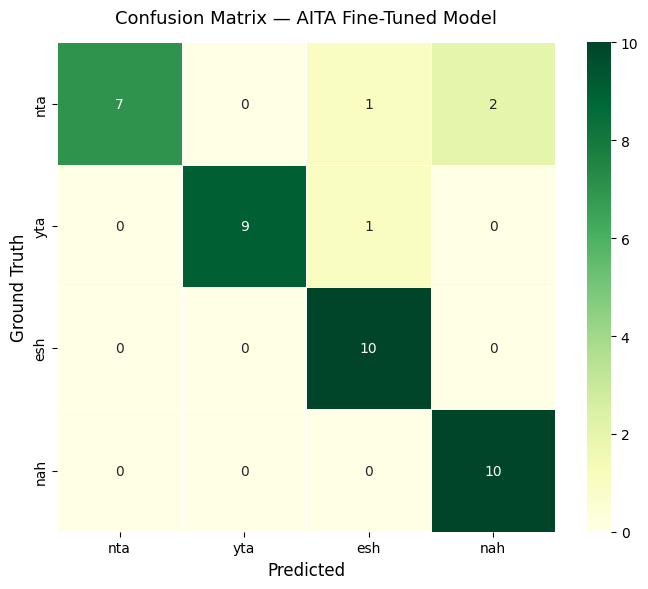

In [9]:
ground_truth = [v.lower() for v in ground_truth]
predictions  = [v.lower() for v in predictions]

cm = confusion_matrix(ground_truth, predictions, labels=VALID_VERDICTS)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=VALID_VERDICTS,
    yticklabels=VALID_VERDICTS,
    linewidths=0.5,
    ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Ground Truth", fontsize=12)
ax.set_title("Confusion Matrix — AITA Fine-Tuned Model", fontsize=13, pad=14)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## <font color= #66b0b0> &ensp; • **Classification Report** </font>

In [10]:
report = classification_report(
    ground_truth,
    predictions,
    labels=VALID_VERDICTS,
    digits=3,
)
print(report)

              precision    recall  f1-score   support

         nta      1.000     0.700     0.824        10
         yta      1.000     0.900     0.947        10
         esh      0.833     1.000     0.909        10
         nah      0.833     1.000     0.909        10

    accuracy                          0.900        40
   macro avg      0.917     0.900     0.897        40
weighted avg      0.917     0.900     0.897        40



## <font color= #66b0b0> &ensp; • **Per-Class Accuracy** </font>

In [11]:
gt_arr   = np.array(ground_truth)
pred_arr = np.array(predictions)

print(f"Overall accuracy: {(gt_arr == pred_arr).mean():.1%}\n")
print("Per-class accuracy:")
for verdict in VALID_VERDICTS:
    mask = gt_arr == verdict
    acc  = (pred_arr[mask] == verdict).mean()
    print(f"  {verdict}: {acc:.1%}  ({mask.sum()} examples)")

Overall accuracy: 90.0%

Per-class accuracy:
  nta: 70.0%  (10 examples)
  yta: 90.0%  (10 examples)
  esh: 100.0%  (10 examples)
  nah: 100.0%  (10 examples)


## <font color= #66b0b0> &ensp; • **Error Analysis** </font>

We look at a random sample of misclassified examples to understand where the model is going wrong. Patterns in the errors — for example, consistently confusing ESH with YTA — are more informative than the numbers alone.

In [12]:
results_df = eval_df[~eval_df["verdict"].isna()].copy().reset_index(drop=True)
results_df = results_df.iloc[:len(predictions)].copy()
results_df["predicted"] = predictions
results_df["correct"]   = results_df["verdict"] == results_df["predicted"]

errors = results_df[~results_df["correct"]]
print(f"Total errors: {len(errors)} / {len(results_df)}\n")

print("Most common confusion pairs (ground truth → predicted):")
print(
    errors.groupby(["verdict", "predicted"])
    .size()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)

Total errors: 4 / 40

Most common confusion pairs (ground truth → predicted):
verdict  predicted
nta      nah          2
         esh          1
yta      esh          1


In [13]:
# Print 5 random misclassified examples for qualitative review
sample_errors = errors.sample(min(5, len(errors)), random_state=RANDOM_SEED)

for _, row in sample_errors.iterrows():
    print("=" * 70)
    print(f"Ground truth : {row['verdict']}")
    print(f"Predicted    : {row['predicted']}")
    print(f"Title        : {row['title']}")
    print(f"Body (first 300 chars): {row['text'][:300]}...")
    print()

Ground truth : nta
Predicted    : nah
Title        : AITA for not attending my father's deathbed after he molested me as a child?
Body (first 300 chars): My father sexually abused me throughout my childhood. I cut contact with him at age 18 and have been in therapy for years. He is now dying and my siblings are begging me to come say goodbye for the sake of family closure. I said no. My siblings say I will regret it and that I am being unforgiving to...

Ground truth : yta
Predicted    : esh
Title        : AITA for telling my stepdaughter I never considered her a real family member?
Body (first 300 chars): I married my husband when his daughter was 4. She is now 19 and has called me mom her entire life. During an argument about her using our home address for college applications I told her that I had never truly thought of her as my daughter, that she was my husband's child and had always felt like a ...

Ground truth : nta
Predicted    : nah
Title        : AITA for refusing to let my 

## <font color= #66b0b0> &ensp; • **Conclusion** </font>

The error analysis reveals a consistent and interpretable pattern: the model systematically shifts predictions toward softer verdicts.

Clear NTA cases are predicted as NAH — the poster's justified refusal to house an abusive mother or attend an abusive father's deathbed gets read as a values difference rather than a clear boundary. Clear YTA cases land on ESH — telling a stepdaughter she was never family is treated as mutual fault rather than one-sided cruelty. The model is not confused about the facts of each situation; it is reluctant to assign full blame or full absolution to either party.

As said before, Haiku rewrote morally charged posts in balanced, even-handed prose, and the model learned that register. It now reads calm, well-structured text as evidence of a nuanced situations so it really is a balance between noisy data and very clean smothed versions, in this case, since we still have a genaerally good model, and not that many errors, we can say the model can identify extreme cases, however, an improvement would be re-modelling after more crude versions of data.

